# Nivel 4. Simulación de escenarios (what-if)

Este notebook extiende el modelo a una herramienta de soporte a decisiones: partiendo de un estado
operativo de referencia, se barren las variables manipulables por el operador (flujos de amina y
almidón, aire y nivel de las columnas, pH) dentro de su rango histórico observado y se cuantifica el
efecto sobre la sílice predicha.

Límites de interpretación, explícitos desde el inicio. El modelo es asociativo: estas son
sensibilidades direccionales, no garantías de control de proceso. No se extrapola fuera del rango
observado. Se cambia un setpoint de la hora actual a la vez, manteniendo fija la trayectoria reciente
de sílice; como el modelo seleccionado predice el cambio respecto a la última medición, cada barrido
responde a la pregunta operativa concreta: dada la trayectoria actual, qué setpoint empuja la próxima
hora hacia arriba o hacia abajo y cuánto.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "config" / "config.yaml").exists():
    if _root == _root.parent:
        raise RuntimeError("No se encontro la raiz del proyecto")
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config, resolve, set_seeds
from src.models.train import fit_winner
from src.simulation.scenarios import reference_state, scenario_scan, sweep_feature, predict_point

cfg = load_config(); set_seeds(cfg["seed"])
sns.set_theme(style="whitegrid", context="notebook")
FIG = resolve(cfg["paths"]["figures_dir"])
model, data = fit_winner(cfg)
X_train = data["X_train"]
reference = reference_state(X_train)
base_pred = predict_point(model, reference)
print("Estado de referencia: mediana de las últimas 720 h de train")
print("Sílice predicha en la referencia: %.3f %%" % base_pred)

Estado de referencia: mediana de las últimas 720 h de train
Sílice predicha en la referencia: 1.662 %


## 1. Barrido de variables manipulables

In [2]:
manipulable = [c for c in X_train.columns if c.endswith("__mean") and any(
    k in c for k in ["Amina Flow", "Starch Flow", "Air Flow", "Level", "Ore Pulp pH"])]
scan = scenario_scan(model, reference, X_train, manipulable, n=21)
print("Variables manipulables barridas:", len(manipulable))
scan.head(10).round(3)

Variables manipulables barridas: 17


,feature,ref_value,range_low,range_high,silica_at_low,silica_at_high,delta_low_to_high,max_abs_delta_vs_ref
0,Flotation Column 03 Air Flow__mean,299.917,219.933,300.037,1.679,1.662,-0.017,0.017
1,Flotation Column 03 Level__mean,498.908,399.356,852.594,1.662,1.651,-0.011,0.011
2,Flotation Column 02 Level__mean,498.220,398.807,800.315,1.662,1.652,-0.009,0.009
3,Flotation Column 07 Level__mean,443.155,347.169,550.891,1.670,1.670,-0.000,0.009
4,Flotation Column 05 Air Flow__mean,299.894,296.017,306.400,1.662,1.670,0.008,0.008
5,Amina Flow__mean,525.913,322.823,598.268,1.662,1.662,0.000,0.000
6,Flotation Column 01 Level__mean,498.807,399.454,801.555,1.662,1.662,0.000,0.000
7,Flotation Column 02 Air Flow__mean,299.840,219.708,300.434,1.662,1.662,0.000,0.000
8,Flotation Column 01 Air Flow__mean,299.897,219.852,300.098,1.662,1.662,0.000,0.000
9,Flotation Column 04 Level__mean,448.154,346.064,549.179,1.662,1.662,0.000,0.000


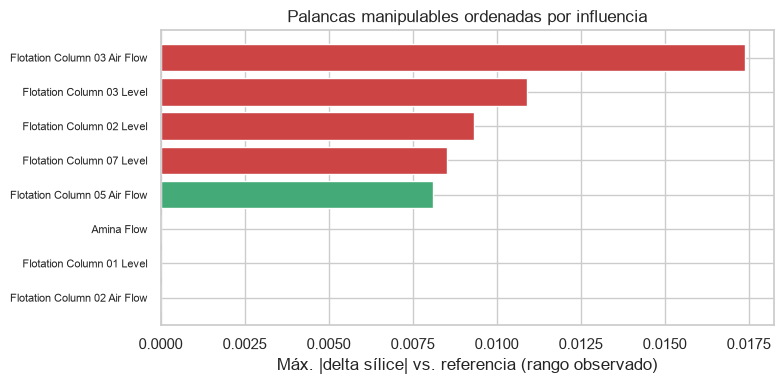

In [3]:
top = scan.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#c44" if d < 0 else "#4a7" for d in top["delta_low_to_high"]]
ax.barh(range(len(top)), top["max_abs_delta_vs_ref"], color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f.replace("__mean", "") for f in top["feature"]], fontsize=8)
ax.set_xlabel("Máx. |delta sílice| vs. referencia (rango observado)")
ax.set_title("Palancas manipulables ordenadas por influencia")
fig.tight_layout(); fig.savefig(FIG / "04_scenario_scan.png", dpi=110); plt.show()

Los efectos individuales son modestos, del orden de una a dos centésimas de punto de sílice dentro del
rango observado. Es coherente con el modelo seleccionado: al predecir el cambio condicionado a la
trayectoria actual, el what-if responde cuánto puede mover un setpoint la próxima hora, no el régimen
de largo plazo. Las palancas más influyentes son el aire y los niveles de las columnas de flotación,
con direcciones coherentes con el análisis SHAP (ver notebook 03): más aire y niveles más altos se
asocian a menor sílice en la próxima hora.

## 2. Curvas de respuesta de las principales palancas

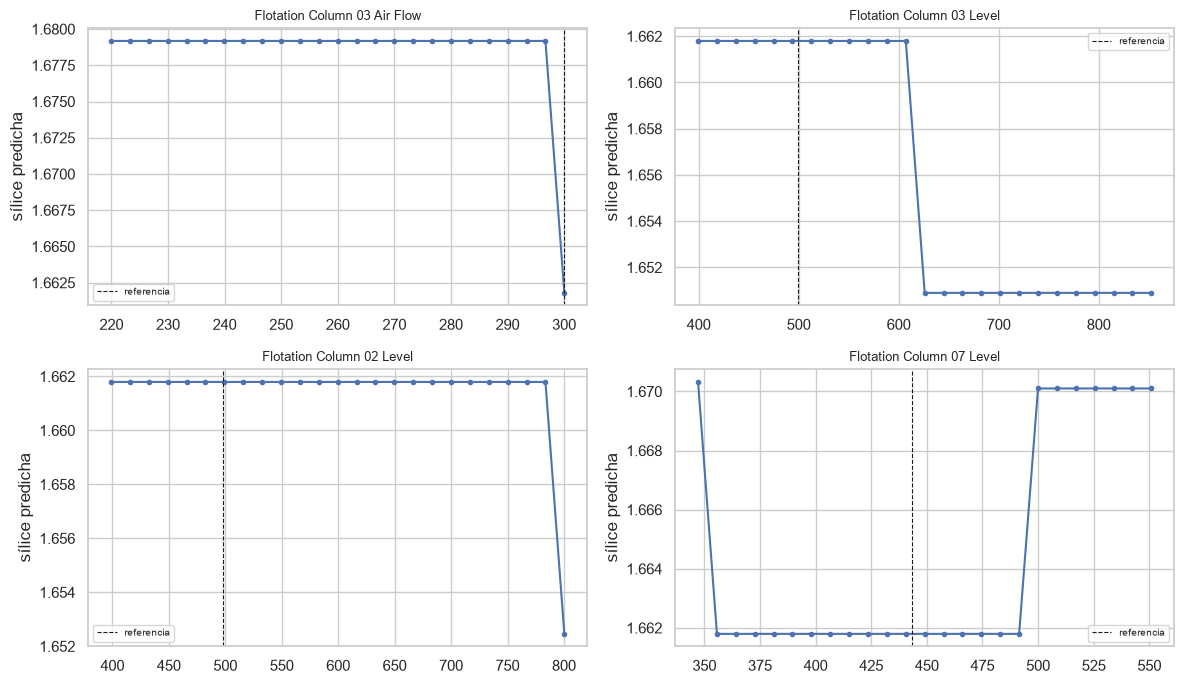

In [4]:
levers = scan["feature"].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, feat in zip(axes.ravel(), levers):
    sw = sweep_feature(model, reference, X_train, feat, n=25)
    ax.plot(sw["value"], sw["pred"], "-o", ms=3)
    ax.axvline(reference[feat], color="k", ls="--", lw=0.8, label="referencia")
    ax.set_title(feat.replace("__mean", ""), fontsize=9)
    ax.set_ylabel("sílice predicha"); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "04_sweeps.png", dpi=110); plt.show()

Las curvas no son lineales: hay tramos planos y umbrales, típicos de un modelo de árboles. La pendiente
local alrededor de la referencia es la lectura operativa relevante; los extremos del rango concentran
menos datos históricos y por eso se interpretan con más cautela.

## 3. Escenarios combinados vs. referencia

In [5]:
# Cota optimista: a cada palanca se le asigna, simultáneamente, el valor de su rango observado que
# minimiza (o maximiza) la sílice. Ignora interacciones y factibilidad conjunta, así que acota el efecto.
best, worst = reference.copy(), reference.copy()
for feat in manipulable:
    sw = sweep_feature(model, reference, X_train, feat, n=25)
    best[feat] = sw.loc[sw["pred"].idxmin(), "value"]
    worst[feat] = sw.loc[sw["pred"].idxmax(), "value"]
best_pred, worst_pred = predict_point(model, best), predict_point(model, worst)
target_range = data["target_range"]
scenarios = pd.DataFrame({
    "escenario": ["referencia", "ajuste hacia menor sílice", "ajuste hacia mayor sílice"],
    "silica_predicha": [base_pred, best_pred, worst_pred],
    "delta_vs_ref": [0.0, best_pred - base_pred, worst_pred - base_pred],
    "delta_%_rango": [0.0, 100*(best_pred - base_pred)/target_range, 100*(worst_pred - base_pred)/target_range],
})
scenarios.round(3)

,escenario,silica_predicha,delta_vs_ref,delta_%_rango
0,referencia,1.662,0.000,0.000
1,ajuste hacia menor sílice,1.642,-0.020,-0.427
2,ajuste hacia mayor sílice,1.687,0.025,0.538


Moviendo simultáneamente todas las palancas manipulables hacia su mejor valor observado, el modelo
estima una reducción del orden de dos centésimas de punto frente a la referencia. Es una cota con dos
lecturas. Primera, es optimista en su construcción: ignora interacciones entre variables y la
factibilidad de fijar todos los setpoints a la vez, y no considera el costo de reactivos. Segunda, es
deliberadamente conservadora en su alcance: mide el efecto sobre la próxima hora condicionado a la
trayectoria actual de la sílice, que es lo único que el modelo puede afirmar con respaldo. El ajuste de
setpoints sostenido en el tiempo desplaza la trayectoria misma, y ese efecto acumulado no se captura en
un what-if de una hora. El control grueso de la calidad ocurre en escalas más lentas (grado del
alimento, régimen de operación) que el modelo no modela a resolución horaria.

## 4. Efecto sostenido: simulación autorregresiva de setpoint

El what-if puntual responde cuánto mueve un setpoint la próxima hora, condicionado a la trayectoria
actual; sostener ese setpoint en el tiempo desplaza la trayectoria misma, y ese efecto acumulado no
aparece en la lectura de una hora. Para estimarlo se itera el modelo delta de forma autorregresiva: la
predicción de cada hora alimenta los features de historia del target de la siguiente (lags, momentum,
medias móviles), con las variables de proceso fijas en la referencia y la palanca sostenida en su valor
óptimo del barrido. La diferencia entre esa trayectoria y la base (mismo rollout sin mover la palanca)
aísla el efecto del setpoint.

Se eligió esta vía y no la comparación de regímenes históricos (cuartiles altos contra bajos de una
palanca) porque los regímenes están confundidos: la planta mueve los setpoints en respuesta a las
condiciones del mineral, así que comparar periodos de dosificación distinta compara condiciones de
operación distintas, no el efecto de la palanca. La simulación usa la estructura del propio modelo y
mantiene el ceteris paribus; su costo es que los errores se acumulan paso a paso y la trayectoria es
una aproximación direccional, no una garantía de control.

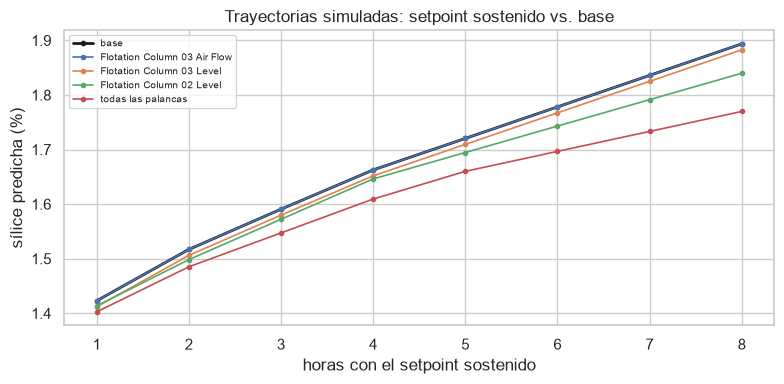

,delta h1,delta h4,delta h8
escenario sostenido,,,
Flotation Column 03 Air Flow,0.000,0.000,0.000
Flotation Column 03 Level,-0.011,-0.011,-0.011
Flotation Column 02 Level,-0.009,-0.016,-0.054
todas las palancas,-0.020,-0.053,-0.124


In [6]:
from src.simulation.scenarios import simulate_sustained

HORIZON = 8
history = data["y_train"].iloc[-12:].reset_index(drop=True)
TARGET = cfg["data"]["target"]

# Valor óptimo (mínima sílice en el barrido horario) de cada palanca.
best_setpoint = {}
for feat in manipulable:
    sw = sweep_feature(model, reference, X_train, feat, n=25)
    best_setpoint[feat] = float(sw.loc[sw["pred"].idxmin(), "value"])

base_traj = simulate_sustained(model, reference, history, TARGET, None, horizon=HORIZON)
top_levers = scan["feature"].head(3).tolist()
trajectories = {"base": base_traj}
for feat in top_levers:
    trajectories[feat] = simulate_sustained(
        model, reference, history, TARGET, {feat: best_setpoint[feat]}, horizon=HORIZON)
trajectories["todas las palancas"] = simulate_sustained(
    model, reference, history, TARGET, best_setpoint, horizon=HORIZON)

rows = []
for name, traj in trajectories.items():
    if name == "base":
        continue
    div = traj - base_traj
    rows.append({"escenario sostenido": name.replace("__mean", ""),
                 "delta h1": div.iloc[0], "delta h4": div.iloc[3],
                 "delta h8": div.iloc[HORIZON - 1]})
sustained = pd.DataFrame(rows).set_index("escenario sostenido")

fig, ax = plt.subplots(figsize=(8, 4))
for name, traj in trajectories.items():
    style = {"lw": 2, "color": "k"} if name == "base" else {"lw": 1.2}
    ax.plot(traj.index, traj.values, "-o", ms=3, label=name.replace("__mean", ""), **style)
ax.set_xlabel("horas con el setpoint sostenido"); ax.set_ylabel("sílice predicha (%)")
ax.set_title("Trayectorias simuladas: setpoint sostenido vs. base")
ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "04_sustained.png", dpi=110); plt.show()
sustained.round(3)

El efecto se acumula: mover todas las palancas a su valor óptimo reduce la sílice en 0.02 puntos la
primera hora (la misma cifra del what-if puntual de la sección 3) pero en torno a 0.12 puntos tras
ocho horas sostenidas, unas seis veces el efecto puntual, porque cada hora de operación mejorada
alimenta la historia sobre la que el modelo predice la siguiente. La lectura operacional: las palancas
no producen saltos, producen deriva; un ajuste mantenido durante un turno tiene un efecto del orden de
una décima de punto de sílice, no de centésimas. También se observa que la palanca más sensible del
barrido horario (el aire de la columna 03) ya está en su valor óptimo en la referencia, así que el
margen sostenido viene sobre todo de los niveles de columna.

Limitaciones, sin suavizar: los errores del modelo se acumulan en cada paso del rollout y no hay
corrección con mediciones reales; el modelo es asociativo, así que la trayectoria hereda toda la
cautela causal del what-if puntual; y el ceteris paribus de ocho horas (alimentación y condiciones
congeladas) es una idealización. El número es una aproximación direccional del orden de magnitud, útil
para priorizar palancas, no una promesa de control.

## 5. Trade-offs y riesgos

- Asociativo, no causal: las sensibilidades reflejan correlaciones históricas; una intervención real
  podría comportarse distinto si rompe la estructura de operación habitual.
- Solo dentro del rango observado: no se simulan valores nunca vistos; fuera de ese rango el modelo no
  tiene evidencia.
- Dependencia de la referencia: los efectos se miden alrededor de un estado concreto; en otro régimen
  las palancas pueden tener pendientes distintas, como muestran las dependencias no lineales del
  notebook 03.
- Costo no modelado: subir aire o reactivos tiene un costo energético y químico que aquí no se pondera.